<a href="https://colab.research.google.com/github/RafaelPradoTorres/pharma-sale/blob/main/pharmacy_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
daily = pd.read_csv("salesdaily.csv")
daily.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [3]:
daily.isna().sum()

,0
datum,0
M01AB,0
M01AE,0
N02BA,0
N02BE,0
N05B,0
N05C,0
R03,0
R06,0
Year,0


In [4]:
daily.describe()

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour
count,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000
mean,5.033683,3.895830,3.880441,29.917095,8.853627,0.593522,5.512262,2.900198,2016.401235,6.344255,275.945869
std,2.737579,2.133337,2.384010,15.590966,5.605605,1.092988,6.428736,2.415816,1.665060,3.386954,1.970547
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2014.000000,1.000000,190.000000
25%,3.000000,2.340000,2.000000,19.000000,5.000000,0.000000,1.000000,1.000000,2015.000000,3.000000,276.000000
50%,4.990000,3.670000,3.500000,26.900000,8.000000,0.000000,4.000000,2.000000,2016.000000,6.000000,276.000000
75%,6.670000,5.138000,5.200000,38.300000,12.000000,1.000000,8.000000,4.000000,2018.000000,9.000000,276.000000
max,17.340000,14.463000,16.000000,161.000000,54.833333,9.000000,45.000000,15.000000,2019.000000,12.000000,276.000000


In [5]:
daily.dtypes

,0
datum,object
M01AB,float64
M01AE,float64
N02BA,float64
N02BE,float64
N05B,float64
N05C,float64
R03,float64
R06,float64
Year,int64


In [6]:
daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         2106 non-null   object 
 1   M01AB         2106 non-null   float64
 2   M01AE         2106 non-null   float64
 3   N02BA         2106 non-null   float64
 4   N02BE         2106 non-null   float64
 5   N05B          2106 non-null   float64
 6   N05C          2106 non-null   float64
 7   R03           2106 non-null   float64
 8   R06           2106 non-null   float64
 9   Year          2106 non-null   int64  
 10  Month         2106 non-null   int64  
 11  Hour          2106 non-null   int64  
 12  Weekday Name  2106 non-null   object 
dtypes: float64(8), int64(3), object(2)
memory usage: 214.0+ KB


array([[<Axes: title={'center': 'M01AB'}>,
        <Axes: title={'center': 'M01AE'}>,
        <Axes: title={'center': 'N02BA'}>],
       [<Axes: title={'center': 'N02BE'}>,
        <Axes: title={'center': 'N05B'}>,
        <Axes: title={'center': 'N05C'}>],
       [<Axes: title={'center': 'R03'}>, <Axes: title={'center': 'R06'}>,
        <Axes: title={'center': 'Year'}>],
       [<Axes: title={'center': 'Month'}>,
        <Axes: title={'center': 'Hour'}>, <Axes: >]], dtype=object)

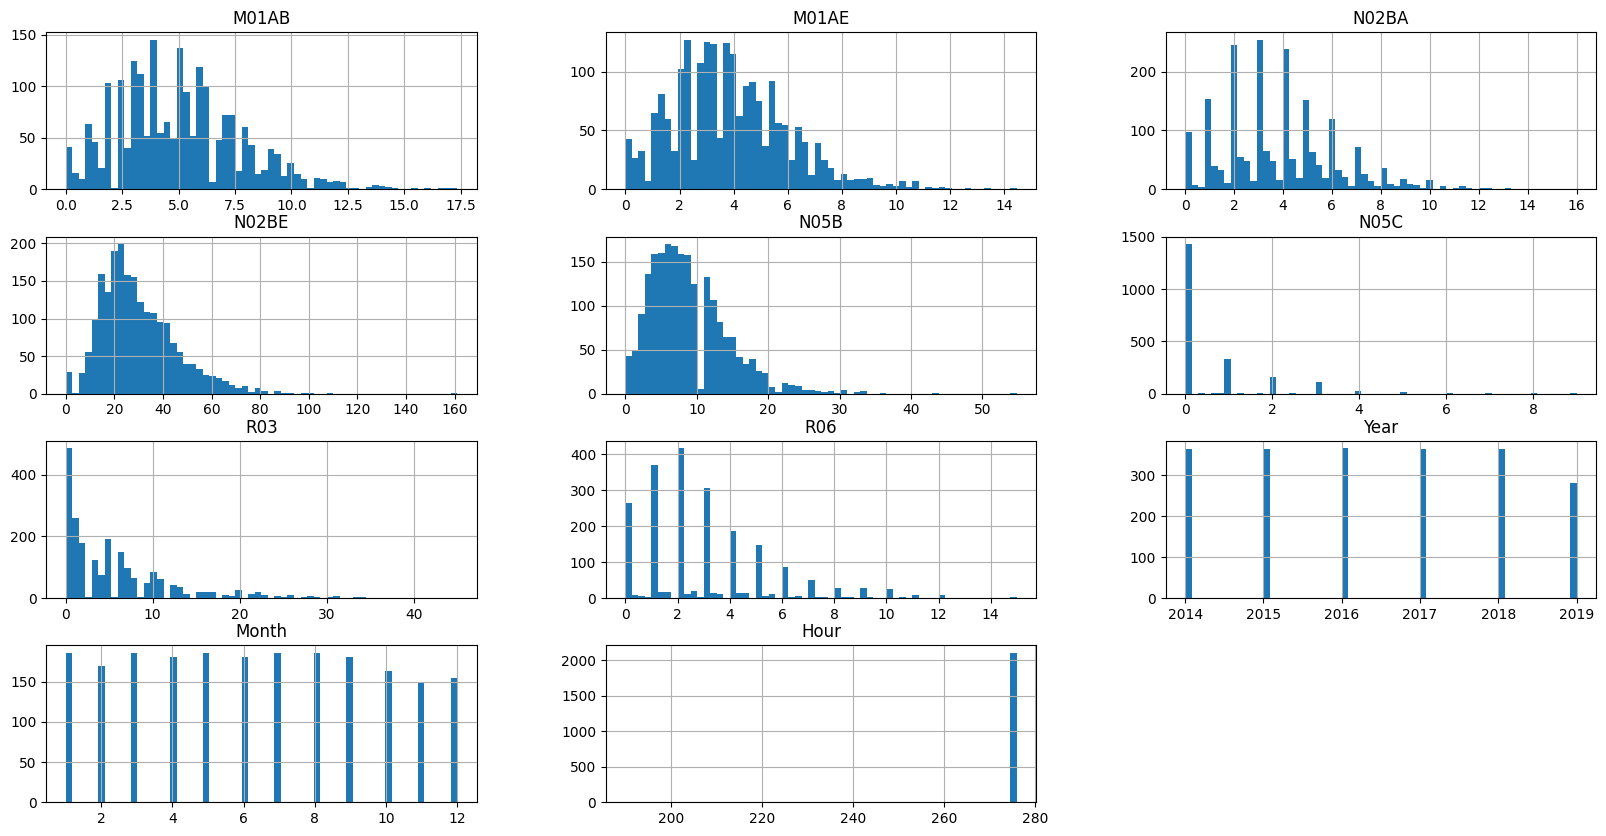

In [7]:
daily.hist(bins=60, figsize=(20,10))

In [8]:
daily.shape

(2106, 13)

In [9]:
daily.columns

Index(['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03',
       'R06', 'Year', 'Month', 'Hour', 'Weekday Name'],
      dtype='object')

In [10]:
drug_cat = daily[['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03',
       'R06']]
total_drug_sales = drug_cat.sum()
total_drug_sales.head(1)

,0
M01AB,10600.937083


<BarContainer object of 8 artists>

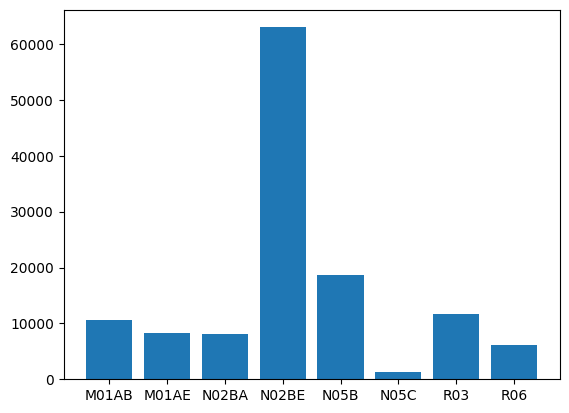

In [11]:
plt.bar(total_drug_sales.index, total_drug_sales.values)

In [12]:
daily.datum = pd.to_datetime(daily.datum)

In [13]:
jan2015 = daily[daily.datum.dt.year == 2015]
jan2015 = jan2015[jan2015.datum.dt.month == 1]
sells_j2015 = jan2015[['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03',
       'R06']].sum()

<BarContainer object of 8 artists>

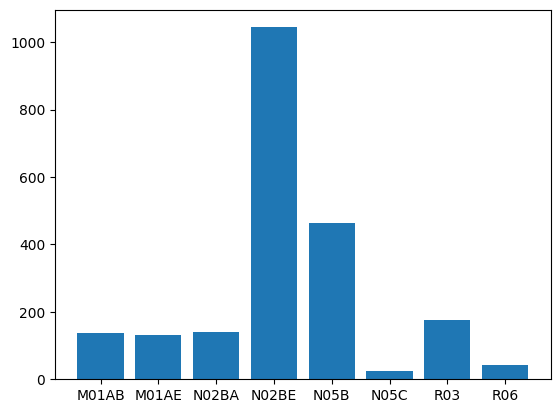

In [14]:
plt.bar(sells_j2015.index, sells_j2015.values)

In [15]:
jul2016 = daily[daily.datum.dt.year == 2016]
jul2016 = jul2016[jul2016.datum.dt.month == 7]
sells_j2016 = jul2016[['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03',
       'R06']].sum()

<BarContainer object of 8 artists>

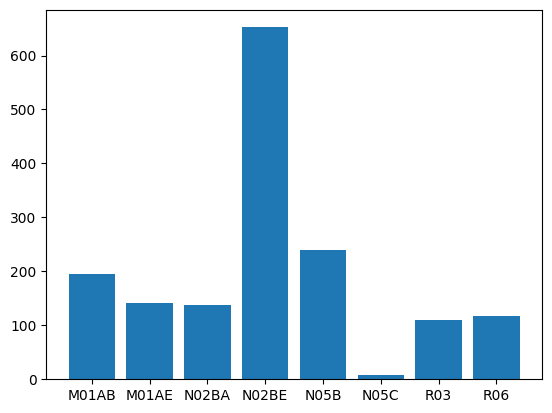

In [16]:
plt.bar(sells_j2016.index, sells_j2016.values)

In [17]:
sep2017 = daily[daily.datum.dt.year == 2017]
sep2017 = sep2017[sep2017.datum.dt.month == 9]
sells_s2017 = sep2017[['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03',
       'R06']].sum()

<BarContainer object of 8 artists>

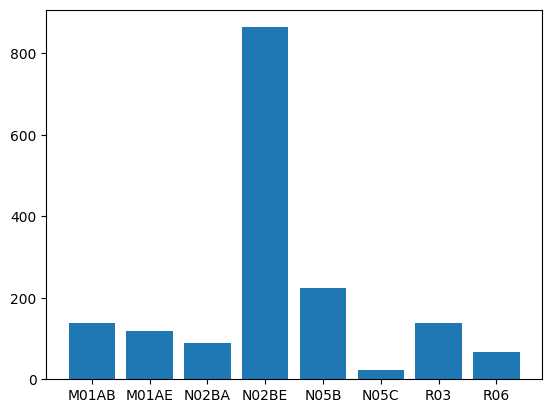

In [18]:
plt.bar(sells_s2017.index, sells_s2017.values)

<BarContainer object of 8 artists>

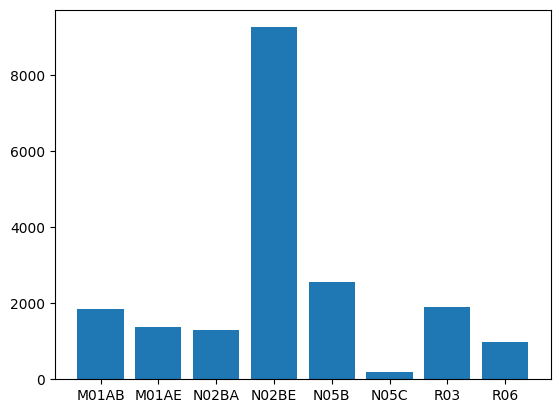

In [19]:
sales2017 = daily[daily.datum.dt.year == 2017]
sum2017 = sales2017[['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03',
       'R06']].sum()
plt.bar(sum2017.index, sum2017.values)

In [20]:
no2019 = daily[daily['Year'] != 2019]
no2019 = no2019.groupby('Month')['R03'].sum()

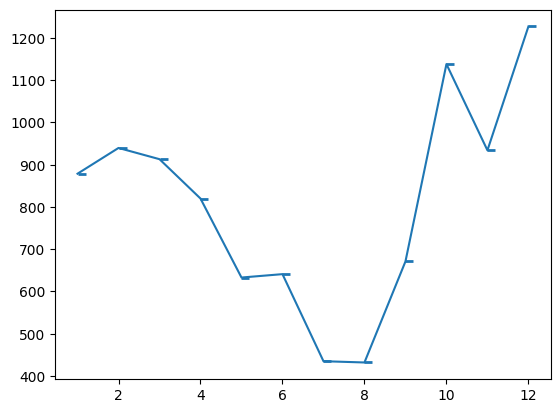

In [21]:
from matplotlib.typing import MarkerType
plt.plot(no2019.index, no2019.values, marker=True, markeredgewidth=2)